**SETUP**

In [97]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [98]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("restaurant_inventory_with_targets.csv")

# Clean hidden spaces in column names
df.columns = df.columns.str.strip()

print("Dataset loaded successfully!")
print(df.head())
print()
print("Columns:")
print(df.columns.tolist())


Dataset loaded successfully!
         Date  Item_ID Item_Name Category Subcategory Unit  Current_Stock  \
0  2025-06-10        1    Paneer      Veg       Dairy   kg          21.45   
1  2025-06-10        2    Tomato      Veg   Vegetable   kg          12.84   
2  2025-06-10        3     Onion      Veg   Vegetable   kg          22.35   
3  2025-06-10        4   Chicken  Non-Veg        Meat   kg           8.36   
4  2025-06-10        5    Mutton  Non-Veg        Meat   kg          12.31   

   Reorder_Level  Daily_Usage  Lead_Time  Price_per_Unit Supplier_Name  \
0           8.12         2.19          1             450    Supplier A   
1           5.34         0.95          4              40    Supplier A   
2           4.49         4.86          4              35    Supplier A   
3           3.16         3.25          3             250    Supplier C   
4           6.19         1.81          3             600    Supplier A   

   Seasonal_Factor  Waste_Percentage  Waste_Adjustment  Invento

In [99]:
# Added realistic datset noise
df["Inventory_To_Order"] += np.random.normal(0, 3, size=len(df))

In [100]:
# ============================================================
# 3. DEFINE TARGET AND FEATURES
# ============================================================

target = "Inventory_To_Order"

features = [
    "Item_Name",
    "Category",
    "Subcategory",
    "Unit",
    "Current_Stock",
    "Reorder_Level",
    "Daily_Usage",
    "Lead_Time",
    "Price_per_Unit",
    "Seasonal_Factor",
    "Waste_Percentage"
]

# Check missing columns before continuing
missing_cols = [col for col in features + [target] if col not in df.columns]

print("Missing columns:", missing_cols)

if missing_cols:
    raise ValueError(f"These columns are missing from the dataset: {missing_cols}")

Missing columns: []


In [101]:
# ============================================================
# 4. CLEAN DATA
# ============================================================

# Convert target to numeric
df[target] = pd.to_numeric(df[target], errors="coerce")

# Convert numeric feature columns
numeric_features = [
    "Current_Stock",
    "Reorder_Level",
    "Daily_Usage",
    "Lead_Time",
    "Price_per_Unit",
    "Seasonal_Factor",
    "Waste_Percentage"
]

for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing values in needed columns
df = df.dropna(subset=features + [target])

print("Cleaned dataset shape:", df.shape)
print(df[features + [target]].head())

Cleaned dataset shape: (1000, 16)
  Item_Name Category Subcategory Unit  Current_Stock  Reorder_Level  \
0    Paneer      Veg       Dairy   kg          21.45           8.12   
1    Tomato      Veg   Vegetable   kg          12.84           5.34   
2     Onion      Veg   Vegetable   kg          22.35           4.49   
3   Chicken  Non-Veg        Meat   kg           8.36           3.16   
4    Mutton  Non-Veg        Meat   kg          12.31           6.19   

   Daily_Usage  Lead_Time  Price_per_Unit  Seasonal_Factor  Waste_Percentage  \
0         2.19          1             450             1.11              2.98   
1         0.95          4              40             0.81              3.54   
2         4.86          4              35             1.23              4.96   
3         3.25          3             250             0.90              3.06   
4         1.81          3             600             1.07              3.09   

   Inventory_To_Order  
0            3.446472  
1         

TARGET VARIABLE STATISTICS

Minimum value:  -4.99 units
Maximum value:  55.85 units
Average mean:   9.50 units
Median:         7.81 units
Std Deviation:  8.56 units

Skewness: 1.57
Note: Target is skewed.


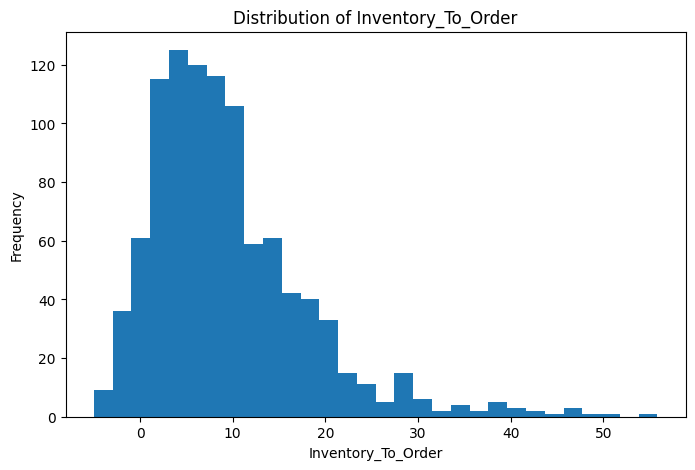

In [102]:
# ============================================================
# 5. TARGET VARIABLE STATISTICS
# ============================================================

target_column = df[target]

print("="*60)
print("TARGET VARIABLE STATISTICS")
print("="*60)
print()

print(f"Minimum value:  {target_column.min():,.2f} units")
print(f"Maximum value:  {target_column.max():,.2f} units")
print(f"Average mean:   {target_column.mean():,.2f} units")
print(f"Median:         {target_column.median():,.2f} units")
print(f"Std Deviation:  {target_column.std():,.2f} units")
print()

skewness = target_column.skew()
print(f"Skewness: {skewness:.2f}")

if abs(skewness) > 1:
    print("Note: Target is skewed.")

# Optional target distribution chart

plt.figure(figsize=(8, 5))
plt.hist(df[target], bins=30)
plt.title("Distribution of Inventory_To_Order")
plt.xlabel("Inventory_To_Order")
plt.ylabel("Frequency")
plt.show()

In [103]:
# ============================================================
# 6. SPLIT FEATURES AND TARGET
# ============================================================

X = df[features]
y = df[target]

categorical_features = [
    "Item_Name",
    "Category",
    "Subcategory",
    "Unit"
]

numeric_features = [
    "Current_Stock",
    "Reorder_Level",
    "Daily_Usage",
    "Lead_Time",
    "Price_per_Unit",
    "Seasonal_Factor",
    "Waste_Percentage"
]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 11)
y shape: (1000,)


In [104]:
# ============================================================
# 7. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 800
Testing rows: 200


In [105]:
# ============================================================
# 8. BUILD RANDOM FOREST PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", rf_model)
    ]
)

print("Pipeline created successfully!")

Pipeline created successfully!


In [106]:
# ============================================================
# 9. TRAIN BASELINE RANDOM FOREST MODEL
# ============================================================

model.fit(X_train, y_train)

print("Baseline Random Forest model trained!")

Baseline Random Forest model trained!


In [107]:
# ============================================================
# 10. EVALUATE BASELINE MODEL
# ============================================================

baseline_preds = model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_r2 = r2_score(y_test, baseline_preds)

print("="*60)
print("BASELINE RANDOM FOREST PERFORMANCE")
print("="*60)
print(f"MAE:  {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"R2:   {baseline_r2:.3f}")

BASELINE RANDOM FOREST PERFORMANCE
MAE:  2.68
RMSE: 3.39
R2:   0.869


In [108]:
# ============================================================
# 11. HYPERPARAMETER TUNING
# ============================================================

param_dist = {
    "regressor__n_estimators": [100, 200, 300, 500],
    "regressor__max_depth": [None, 5, 10, 20, 30],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

print("HPT complete!")
print("Best parameters:")
print(random_search.best_params_)
print()
print("Best CV RMSE:")
print(-random_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
HPT complete!
Best parameters:
{'regressor__n_estimators': 300, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 2, 'regressor__max_features': None, 'regressor__max_depth': None}

Best CV RMSE:
3.3401916929837747


In [109]:
# ============================================================
# 12. EVALUATE TUNED MODEL
# ============================================================

best_model = random_search.best_estimator_

tuned_preds = best_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_r2 = r2_score(y_test, tuned_preds)

print("="*60)
print("TUNED RANDOM FOREST PERFORMANCE")
print("="*60)
print(f"MAE:  {tuned_mae:.2f}")
print(f"RMSE: {tuned_rmse:.2f}")
print(f"R2:   {tuned_r2:.3f}")

TUNED RANDOM FOREST PERFORMANCE
MAE:  2.66
RMSE: 3.39
R2:   0.869


In [110]:
# ============================================================
# 13. COMPARE BASELINE VS TUNED MODEL
# ============================================================

comparison = pd.DataFrame({
    "Model": ["Baseline Random Forest", "Tuned Random Forest"],
    "MAE": [baseline_mae, tuned_mae],
    "RMSE": [baseline_rmse, tuned_rmse],
    "R2": [baseline_r2, tuned_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Baseline Random Forest,2.682773,3.391408,0.869006
1,Tuned Random Forest,2.662051,3.391195,0.869022


In [111]:
# ============================================================
# 14. TEST ONE SAMPLE PREDICTION
# ============================================================

sample = X_test.iloc[[0]]
actual_value = y_test.iloc[0]
predicted_value = best_model.predict(sample)[0]

print("Sample Input:")
print(sample)
print()
print(f"Actual Inventory_To_Order:    {actual_value:.2f}")
print(f"Predicted Inventory_To_Order: {predicted_value:.2f}")

Sample Input:
    Item_Name Category Subcategory Unit  Current_Stock  Reorder_Level  \
521    Tomato      Veg   Vegetable   kg          11.63           7.35   

     Daily_Usage  Lead_Time  Price_per_Unit  Seasonal_Factor  Waste_Percentage  
521          2.5          1              40             1.19              1.26  

Actual Inventory_To_Order:    1.62
Predicted Inventory_To_Order: 4.06


In [112]:
# ============================================================
# 15. SAVE FINAL MODEL
# ============================================================

joblib.dump(best_model, "reorder_model_tuned.pkl")

print("Final tuned model saved as reorder_model_tuned.pkl")

Final tuned model saved as reorder_model_tuned.pkl


In [113]:
# ============================================================
# 16. LOAD MODEL TEST
# ============================================================

loaded_model = joblib.load("reorder_model_tuned.pkl")

test_prediction = loaded_model.predict(sample)[0]

print(f"Loaded model prediction: {test_prediction:.2f}")

Loaded model prediction: 4.06
